# Étape 1 — Exploration et préparation des données

Pipeline MLOps de scoring de risque de crédit — dataset Home Credit.  
Ce notebook couvre les phases 1 à 4 : exploration, nettoyage, feature engineering et préparation pour le modèle.

## Phase 1 — Découverte des données

---

### 1.1 Chargement des fichiers

**Objectif** : Charger tous les fichiers CSV et en faire un premier aperçu.

In [2]:
import pandas as pd
pd.set_option('display.max_columns', None)


DATA_PATH = '/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/data/'

#### application_train.csv

In [3]:
application_train = pd.read_csv(DATA_PATH + 'application_train.csv')
print(f'Shape: {application_train.shape}')
application_train.info()

Shape: (307511, 122)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [4]:
application_train

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.0220,0.0198,0.0,0.0000,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.0000,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.0790,0.0554,0.0,0.0000,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.0100,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

#### application_test.csv

In [5]:
application_test = pd.read_csv(DATA_PATH + 'application_test.csv')
print(f'Shape: {application_test.shape}')
application_test.info()

Shape: (48744, 121)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Columns: 121 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(40), object(16)
memory usage: 45.0+ MB


#### bureau.csv

In [6]:
bureau = pd.read_csv(DATA_PATH + 'bureau.csv')
print(f'Shape: {bureau.shape}')
bureau.info()

Shape: (1716428, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB


#### bureau_balance.csv

In [7]:
bureau_balance = pd.read_csv(DATA_PATH + 'bureau_balance.csv')
print(f'Shape: {bureau_balance.shape}')
bureau_balance.info()

Shape: (27299925, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27299925 entries, 0 to 27299924
Data columns (total 3 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   SK_ID_BUREAU    int64 
 1   MONTHS_BALANCE  int64 
 2   STATUS          object
dtypes: int64(2), object(1)
memory usage: 624.8+ MB


#### credit_card_balance.csv

In [8]:
credit_card_balance = pd.read_csv(DATA_PATH + 'credit_card_balance.csv')
print(f'Shape: {credit_card_balance.shape}')
credit_card_balance.info()

Shape: (3840312, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3840312 entries, 0 to 3840311
Data columns (total 23 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   SK_ID_PREV                  int64  
 1   SK_ID_CURR                  int64  
 2   MONTHS_BALANCE              int64  
 3   AMT_BALANCE                 float64
 4   AMT_CREDIT_LIMIT_ACTUAL     int64  
 5   AMT_DRAWINGS_ATM_CURRENT    float64
 6   AMT_DRAWINGS_CURRENT        float64
 7   AMT_DRAWINGS_OTHER_CURRENT  float64
 8   AMT_DRAWINGS_POS_CURRENT    float64
 9   AMT_INST_MIN_REGULARITY     float64
 10  AMT_PAYMENT_CURRENT         float64
 11  AMT_PAYMENT_TOTAL_CURRENT   float64
 12  AMT_RECEIVABLE_PRINCIPAL    float64
 13  AMT_RECIVABLE               float64
 14  AMT_TOTAL_RECEIVABLE        float64
 15  CNT_DRAWINGS_ATM_CURRENT    float64
 16  CNT_DRAWINGS_CURRENT        int64  
 17  CNT_DRAWINGS_OTHER_CURRENT  float64
 18  CNT_DRAWINGS_POS_CURRENT    float64
 19  

#### installments_payments.csv

In [9]:
installments_payments = pd.read_csv(DATA_PATH + 'installments_payments.csv')
print(f'Shape: {installments_payments.shape}')
installments_payments.info()

Shape: (13605401, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB


#### POS_CASH_balance.csv

In [10]:
pos_cash_balance = pd.read_csv(DATA_PATH + 'POS_CASH_balance.csv')
print(f'Shape: {pos_cash_balance.shape}')
pos_cash_balance.info()

Shape: (10001358, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB


#### previous_application.csv

In [11]:
previous_application = pd.read_csv(DATA_PATH + 'previous_application.csv')
print(f'Shape: {previous_application.shape}')
previous_application.info()

Shape: (1670214, 37)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT    

#### HomeCredit_columns_description.csv

In [12]:
columns_description = pd.read_csv(DATA_PATH + 'HomeCredit_columns_description.csv', encoding='latin-1')
print(f'Shape: {columns_description.shape}')
columns_description.info()

Shape: (219, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219 entries, 0 to 218
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   219 non-null    int64 
 1   Table        219 non-null    object
 2   Row          219 non-null    object
 3   Description  219 non-null    object
 4   Special      86 non-null     object
dtypes: int64(1), object(4)
memory usage: 8.7+ KB


In [13]:
# Voir la description complète de TARGET dans le dictionnaire
print(columns_description[columns_description['Row'] == 'TARGET']['Description'].values[0])

Target variable (1 - client with payment difficulties: he/she had late payment more than X days on at least one of the first Y installments of the loan in our sample, 0 - all other cases)


#### sample_submission.csv

In [14]:
sample_submission = pd.read_csv(DATA_PATH + 'sample_submission.csv')
print(f'Shape: {sample_submission.shape}')
sample_submission.info()

Shape: (48744, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SK_ID_CURR  48744 non-null  int64  
 1   TARGET      48744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 761.8 KB


In [16]:
# Toutes les descriptions des colonnes de application_train
app_desc = columns_description[
    columns_description['Table'] == 'application_{train|test}.csv'
][['Row', 'Description']]

print(f"Nombre de colonnes décrites : {len(app_desc)}")
display(app_desc)

Nombre de colonnes décrites : 122


,Row,Description
0,SK_ID_CURR,ID of loan in our sample
1,TARGET,Target variable (1 - client with payment diffi...
2,NAME_CONTRACT_TYPE,Identification if loan is cash or revolving
3,CODE_GENDER,Gender of the client
4,FLAG_OWN_CAR,Flag if the client owns a car
...,...,...
117,AMT_REQ_CREDIT_BUREAU_DAY,Number of enquiries to Credit Bureau about the...
118,AMT_REQ_CREDIT_BUREAU_WEEK,Number of enquiries to Credit Bureau about the...
119,AMT_REQ_CREDIT_BUREAU_MON,Number of enquiries to Credit Bureau about the...
120,AMT_REQ_CREDIT_BUREAU_QRT,Number of enquiries to Credit Bureau about the...


### Aperçu rapide — Distribution de TARGET

Premier regard sur l'équilibre de la variable cible. L'analyse visuelle complète, avec graphique et implications, est dans la section **1.3**.

In [17]:
# Distribution de la variable cible TARGET
print("Distribution TARGET :")
print(application_train['TARGET'].value_counts())
print(f"\nDéséquilibre : {application_train['TARGET'].mean():.1%} de mauvais clients")

Distribution TARGET :
TARGET
0    282686
1     24825
Name: count, dtype: int64

Déséquilibre : 8.1% de mauvais clients


---

## Résumé — 1.1 Chargement des fichiers

| Fichier | Lignes | Colonnes | Rôle |
|---|---|---|---|
| **application_train** | 307 511 | 122 | Données d'entraînement avec TARGET |
| **application_test** | 48 744 | 121 | Données de soumission Kaggle (sans TARGET) |
| **bureau** | 1 716 428 | 17 | Historique crédits bureau |
| **bureau_balance** | 27 299 925 | 3 | Soldes mensuels crédits bureau |
| **credit_card_balance** | 3 840 312 | 23 | Soldes cartes de crédit |
| **installments_payments** | 13 605 401 | 8 | Paiements d'échéances |
| **POS_CASH_balance** | 10 001 358 | 8 | Soldes POS et cash |
| **previous_application** | 1 670 214 | 37 | Demandes précédentes de crédit |
| **sample_submission** | 48 744 | 2 | Format de soumission Kaggle |

**Décisions clés :**
- Seuls `application_train` et `application_test` servent respectivement à l'entraînement et à la prédiction.
- Les tables secondaires seront agrégées par `SK_ID_CURR` en **Phase 3**.
- `DAYS_EMPLOYED == 365 243` est une valeur sentinelle ("sans emploi") — à remplacer en **Phase 2**.

---

## Phase 1 — 1.2 Forme et types des données

### Objectif
Comparer `application_train` et `application_test` pour comprendre leurs différences structurelles, et expliquer pourquoi `application_test` **ne peut pas** être utilisé pour l'entraînement d'un modèle.

### Étape 1 — Dimensions de chaque dataset

On regarde combien de lignes (clients) et de colonnes (variables) contient chaque fichier.

In [19]:
# Dimensions de chaque dataset
print("=" * 50)
print("DIMENSIONS DES DATASETS")
print("=" * 50)
print(f"application_train : {application_train.shape[0]:>7} lignes × {application_train.shape[1]} colonnes")
print(f"application_test  : {application_test.shape[0]:>7} lignes × {application_test.shape[1]} colonnes")
print("=" * 50)

DIMENSIONS DES DATASETS
application_train :  307511 lignes × 122 colonnes
application_test  :   48744 lignes × 121 colonnes


### Étape 2 — Types de colonnes (int, float, object)

`.dtypes.value_counts()` compte combien de colonnes appartiennent à chaque type : numérique entier (`int64`), numérique décimal (`float64`), ou texte (`object`).

In [20]:
# Types de colonnes par dataset
print("=" * 50)
print("TYPES DE COLONNES — application_train")
print("=" * 50)
print(application_train.dtypes.value_counts().to_string())

print("\n" + "=" * 50)
print("TYPES DE COLONNES — application_test")
print("=" * 50)
print(application_test.dtypes.value_counts().to_string())

TYPES DE COLONNES — application_train
float64    65
int64      41
object     16

TYPES DE COLONNES — application_test
float64    65
int64      40
object     16


### Étape 3 — Comparaison des colonnes : train vs test

On cherche les colonnes présentes dans un dataset mais absentes de l'autre.
Un décalage révèle une information que l'un possède et l'autre non.

In [21]:
# Colonnes présentes dans train mais absentes dans test
cols_train_only = set(application_train.columns) - set(application_test.columns)

# Colonnes présentes dans test mais absentes dans train
cols_test_only = set(application_test.columns) - set(application_train.columns)

print("=" * 50)
print("COLONNES DANS TRAIN mais PAS dans TEST")
print("=" * 50)
print(cols_train_only if cols_train_only else "  Aucune")

print("\n" + "=" * 50)
print("COLONNES DANS TEST mais PAS dans TRAIN")
print("=" * 50)
print(cols_test_only if cols_test_only else "  Aucune")

COLONNES DANS TRAIN mais PAS dans TEST
{'TARGET'}

COLONNES DANS TEST mais PAS dans TRAIN
  Aucune


### Étape 4 — Vérification explicite de TARGET dans chaque dataset

`TARGET` est la variable que le modèle doit apprendre à prédire.
Sans elle, impossible d'entraîner : on ne saurait pas quoi prédire !

In [22]:
# Vérification de la présence de TARGET dans chaque dataset
def check_target(df, name):
    if 'TARGET' in df.columns:
        n_vals = df['TARGET'].notna().sum()
        print(f"  ✓ TARGET présente dans {name} — {n_vals} valeurs non-nulles")
    else:
        print(f"  ✗ TARGET ABSENTE dans {name}")

print("=" * 50)
print("PRÉSENCE DE LA VARIABLE TARGET")
print("=" * 50)
check_target(application_train, "application_train")
check_target(application_test,  "application_test")
print("=" * 50)

PRÉSENCE DE LA VARIABLE TARGET
  ✓ TARGET présente dans application_train — 307511 valeurs non-nulles
  ✗ TARGET ABSENTE dans application_test


---

## Résumé — 1.2 Forme et types des données

| Caractéristique | `application_train` | `application_test` |
|---|---|---|
| Lignes (clients) | 307 511 | 48 744 |
| Colonnes | 122 | 121 |
| float64 | 65 | 65 |
| int64 | 41 | 40 |
| object (texte) | 16 | 16 |
| Colonne TARGET | **OUI** ✓ | **NON** ✗ |

### Pourquoi application_test est inutilisable pour l'entraînement ?

`application_test` est un fichier de **compétition Kaggle** : il contient les données de clients dont on veut prédire le risque, mais **sans la réponse** (`TARGET` absente).

Un algorithme de machine learning supervisé apprend en observant des exemples **avec** leur étiquette correcte (`TARGET = 0` ou `1`). Sans cette étiquette, le modèle n'a rien à apprendre.

**Conséquence pratique :**
- `application_train` → sert à **entraîner et évaluer** le modèle (on connaît le résultat réel)
- `application_test` → sert uniquement à **produire des prédictions** à soumettre sur Kaggle (on ne connaît pas le résultat réel)

> La seule différence structurelle entre les deux fichiers est l'absence de `TARGET` dans le test : **1 colonne manquante**, mais c'est précisément celle qui rend l'entraînement possible.

---

## Phase 1 — 1.3 La variable cible (TARGET)

### Objectif
Comprendre la **distribution de TARGET** : combien de bons clients (0) vs mauvais clients (1), et ce que ce déséquilibre implique pour le modèle.

### Étape 1 — Distribution de TARGET en chiffres

On compte le nombre de clients par classe et on calcule les pourcentages.

In [23]:
# Distribution de TARGET : effectifs et pourcentages
counts = application_train['TARGET'].value_counts().sort_index()
pcts   = application_train['TARGET'].value_counts(normalize=True).sort_index() * 100

print("=" * 50)
print("DISTRIBUTION DE LA VARIABLE TARGET")
print("=" * 50)
print(f"  0 — Bon client    : {counts[0]:>7}  ({pcts[0]:.1f} %)")
print(f"  1 — Mauvais client: {counts[1]:>7}  ({pcts[1]:.1f} %)")
print("-" * 50)
print(f"  Total             : {counts.sum():>7}  (100.0 %)")
print("=" * 50)
print(f"\n  Déséquilibre : 1 mauvais client pour {counts[0] // counts[1]:.0f} bons clients")

DISTRIBUTION DE LA VARIABLE TARGET
  0 — Bon client    :  282686  (91.9 %)
  1 — Mauvais client:   24825  (8.1 %)
--------------------------------------------------
  Total             :  307511  (100.0 %)

  Déséquilibre : 1 mauvais client pour 11 bons clients


### Étape 2 — Visualisation : graphique en barres

Un graphique permet de rendre le déséquilibre immédiatement visible à l'œil.

Graphique sauvegardé : graphiques/target_distribution.png


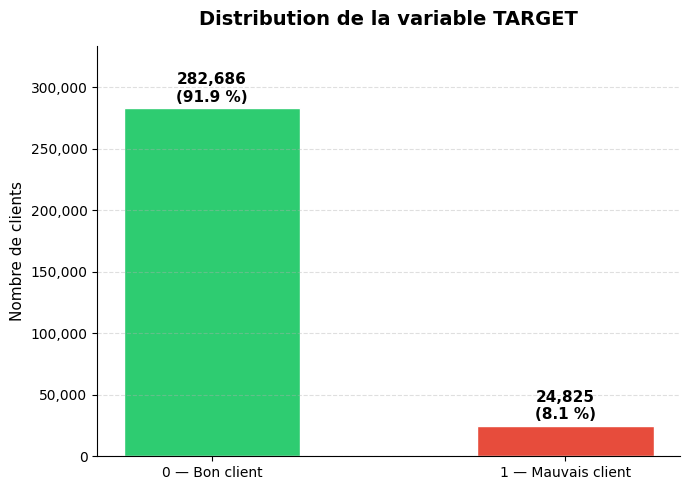

In [24]:
import matplotlib.pyplot as plt
import os

fig, ax = plt.subplots(figsize=(7, 5))

labels = ['0 — Bon client', '1 — Mauvais client']
colors = ['#2ecc71', '#e74c3c']  # vert, rouge

bars = ax.bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)

# Valeur exacte + pourcentage au-dessus de chaque barre
for bar, count, pct in zip(bars, counts.values, pcts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 3000,
        f"{count:,}\n({pct:.1f} %)",
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_title("Distribution de la variable TARGET", fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel("Nombre de clients", fontsize=11)
ax.set_ylim(0, counts.max() * 1.18)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

# Sauvegarde dans graphiques/
GRAPH_PATH = os.path.join(os.path.dirname('/home/bdb/Bureau/P6/Initiez-vous-au-MLOps/notebook.ipynb'), 'graphiques')
plt.savefig(os.path.join(GRAPH_PATH, 'target_distribution.png'), dpi=150, bbox_inches='tight')
print(f"Graphique sauvegardé : graphiques/target_distribution.png")

plt.show()

---

## Résumé — 1.3 La variable cible (TARGET)

| Classe | Signification | Effectif | Proportion |
|---|---|---|---|
| **0** | Bon client (remboursement OK) | 282 686 | 91,9 % |
| **1** | Mauvais client (difficultés de paiement) | 24 825 | 8,1 % |

**Ratio de déséquilibre :** environ 1 mauvais client pour 11 bons clients.

**Implication pour la modélisation :** ce fort déséquilibre (8 % vs 92 %) signifie qu'un modèle naïf qui prédit toujours 0 aurait déjà 91,9 % de précision — il faudra utiliser des techniques comme le rééchantillonnage (SMOTE, under-sampling) ou ajuster les poids des classes pour que le modèle apprenne réellement à détecter les mauvais payeurs.

---

## Phase 1 — 1.4 Valeurs manquantes

### Objectif
Identifier les colonnes incomplètes dans `application_train` et visualiser leur taux de remplissage — en filtrant sur les colonnes concernées pour que le graphique reste lisible.

### Étape 1 — Identifier les colonnes avec des valeurs manquantes

On filtre sur les colonnes qui ont au moins 1 NaN, puis on affiche combien sont concernées.

In [25]:
# Colonnes avec au moins 1 valeur manquante
mask_nan = application_train.isnull().sum() > 0
cols_manquantes = application_train.columns[mask_nan].tolist()

total_cols = application_train.shape[1]
print("=" * 50)
print("VALEURS MANQUANTES — application_train")
print("=" * 50)
print(f"  Colonnes avec NaN : {len(cols_manquantes)} sur {total_cols}")
print(f"  Colonnes complètes: {total_cols - len(cols_manquantes)} sur {total_cols}")
print("=" * 50)

VALEURS MANQUANTES — application_train
  Colonnes avec NaN : 67 sur 122
  Colonnes complètes: 55 sur 122


### Étape 2 — Tableau des taux de valeurs manquantes

Classement du plus incomplet au plus complet, avec le nombre brut et le pourcentage.

In [26]:
# Tableau classé par taux de NaN décroissant
n_rows = application_train.shape[0]
nan_counts = application_train[cols_manquantes].isnull().sum()

tableau_nan = pd.DataFrame({
    'nb_manquants': nan_counts,
    'pct_manquants': (nan_counts / n_rows * 100).round(1)
}).sort_values('pct_manquants', ascending=False)

print(f"{'Colonne':<45} {'NaN':>7} {'%':>7}")
print("-" * 62)
for col, row in tableau_nan.iterrows():
    print(f"{col:<45} {int(row['nb_manquants']):>7,} {row['pct_manquants']:>6.1f}%")

Colonne                                           NaN       %
--------------------------------------------------------------
COMMONAREA_MEDI                               214,865   69.9%
COMMONAREA_AVG                                214,865   69.9%
COMMONAREA_MODE                               214,865   69.9%
NONLIVINGAPARTMENTS_MEDI                      213,514   69.4%
NONLIVINGAPARTMENTS_MODE                      213,514   69.4%
NONLIVINGAPARTMENTS_AVG                       213,514   69.4%
LIVINGAPARTMENTS_MODE                         210,199   68.4%
LIVINGAPARTMENTS_MEDI                         210,199   68.4%
LIVINGAPARTMENTS_AVG                          210,199   68.4%
FONDKAPREMONT_MODE                            210,295   68.4%
FLOORSMIN_MODE                                208,642   67.8%
FLOORSMIN_MEDI                                208,642   67.8%
FLOORSMIN_AVG                                 208,642   67.8%
YEARS_BUILD_MODE                              204,488   66.5%
YEARS_B

### Étape 3 — Patterns de valeurs manquantes (colonnes > 40 % de NaN)

On filtre les colonnes avec plus de 40 % de NaN et on trace `msno.matrix` pour visualiser les **patterns** de valeurs manquantes.

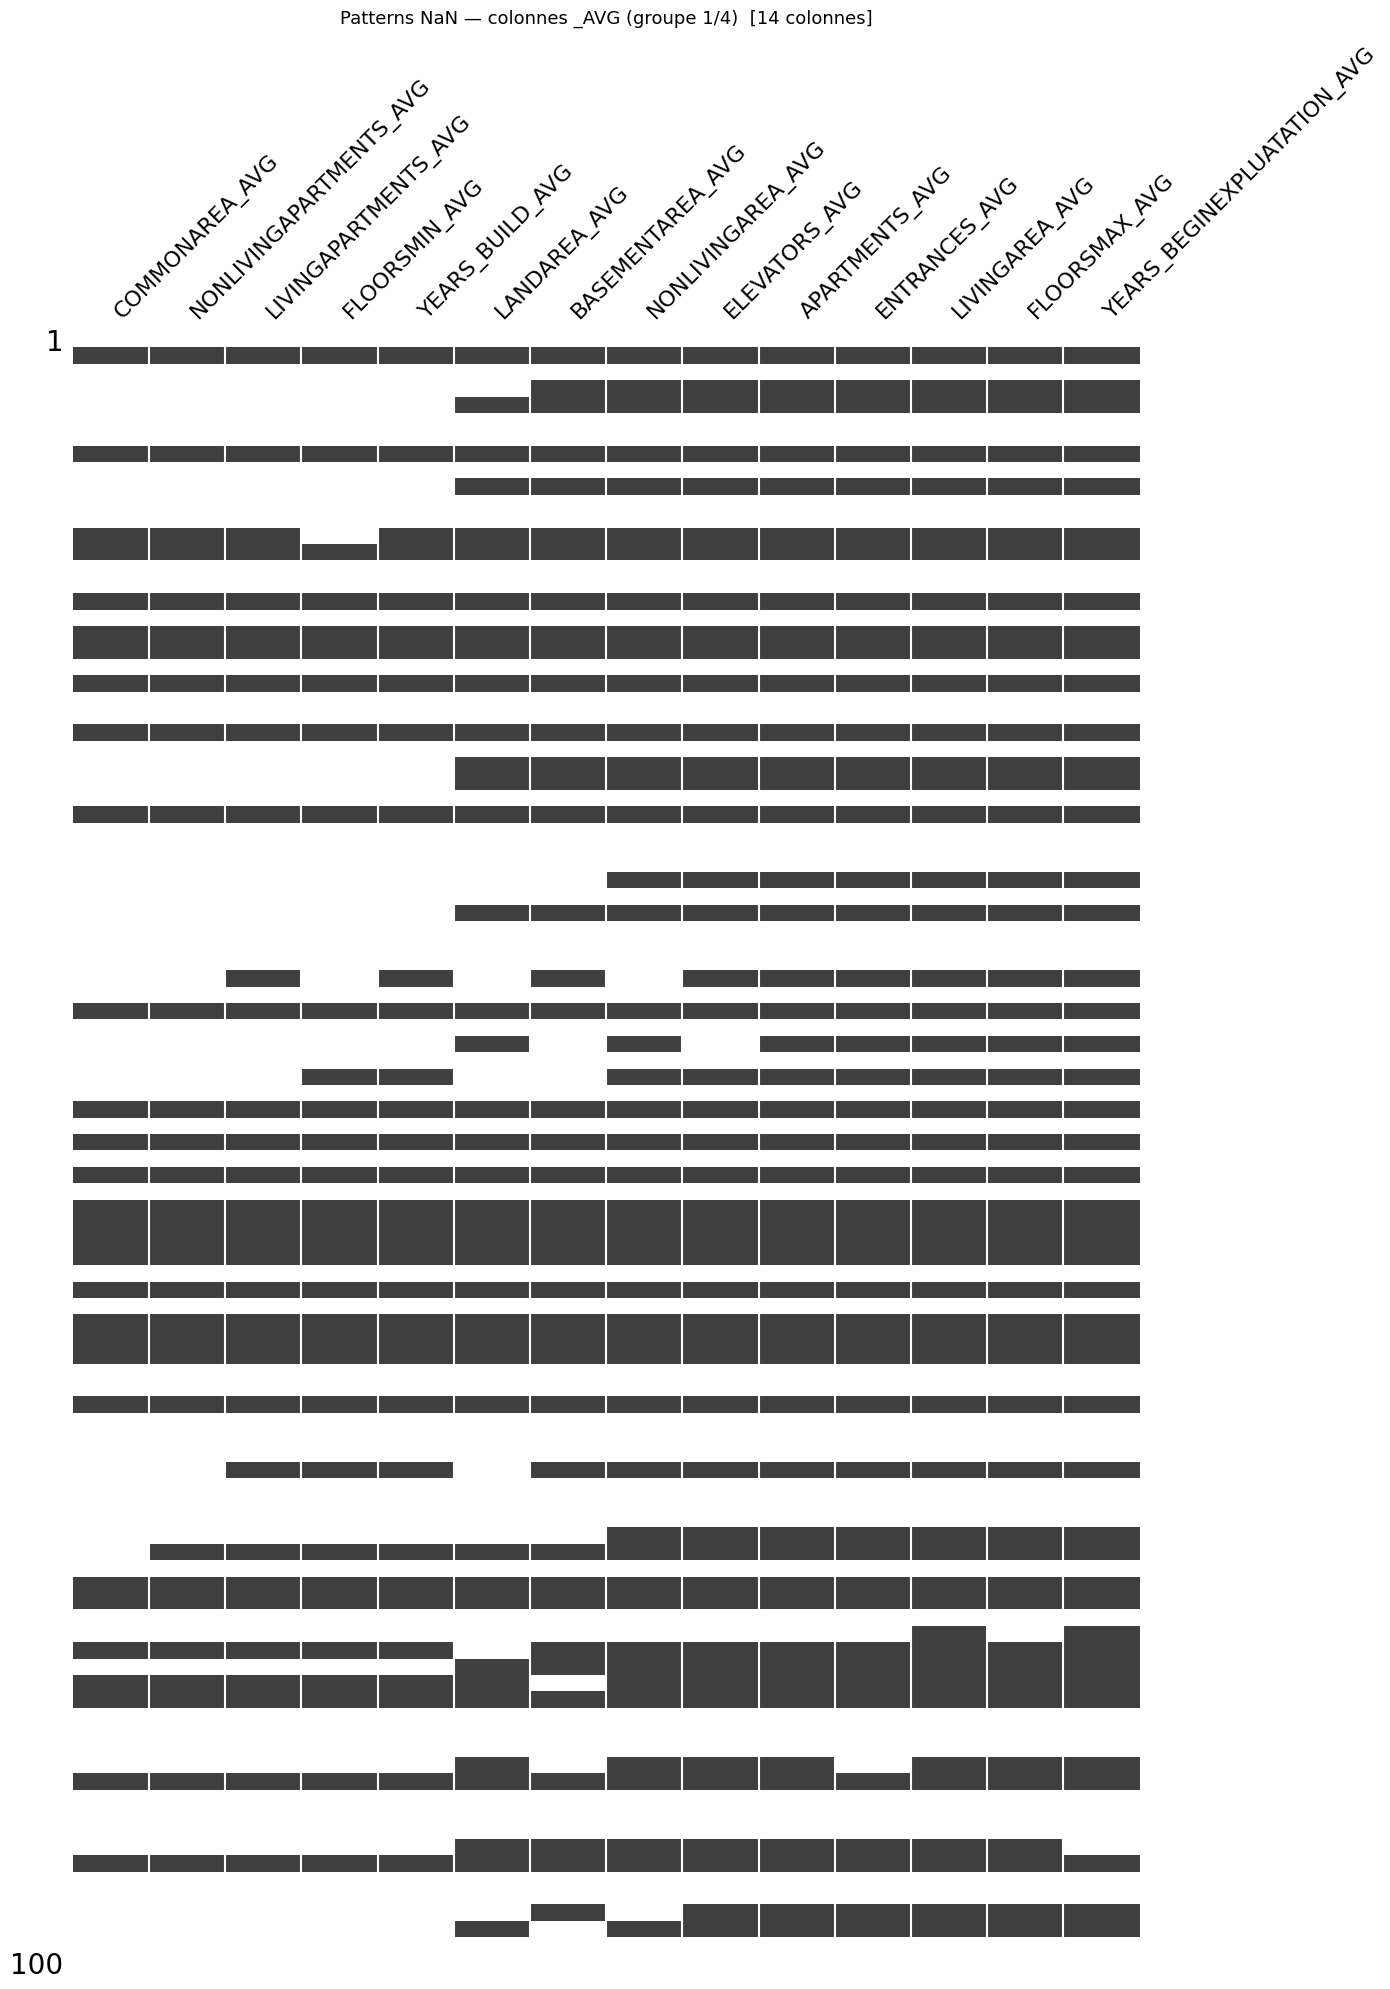

Graphique sauvegardé : graphiques/missingno_avg.png  (14 colonnes)


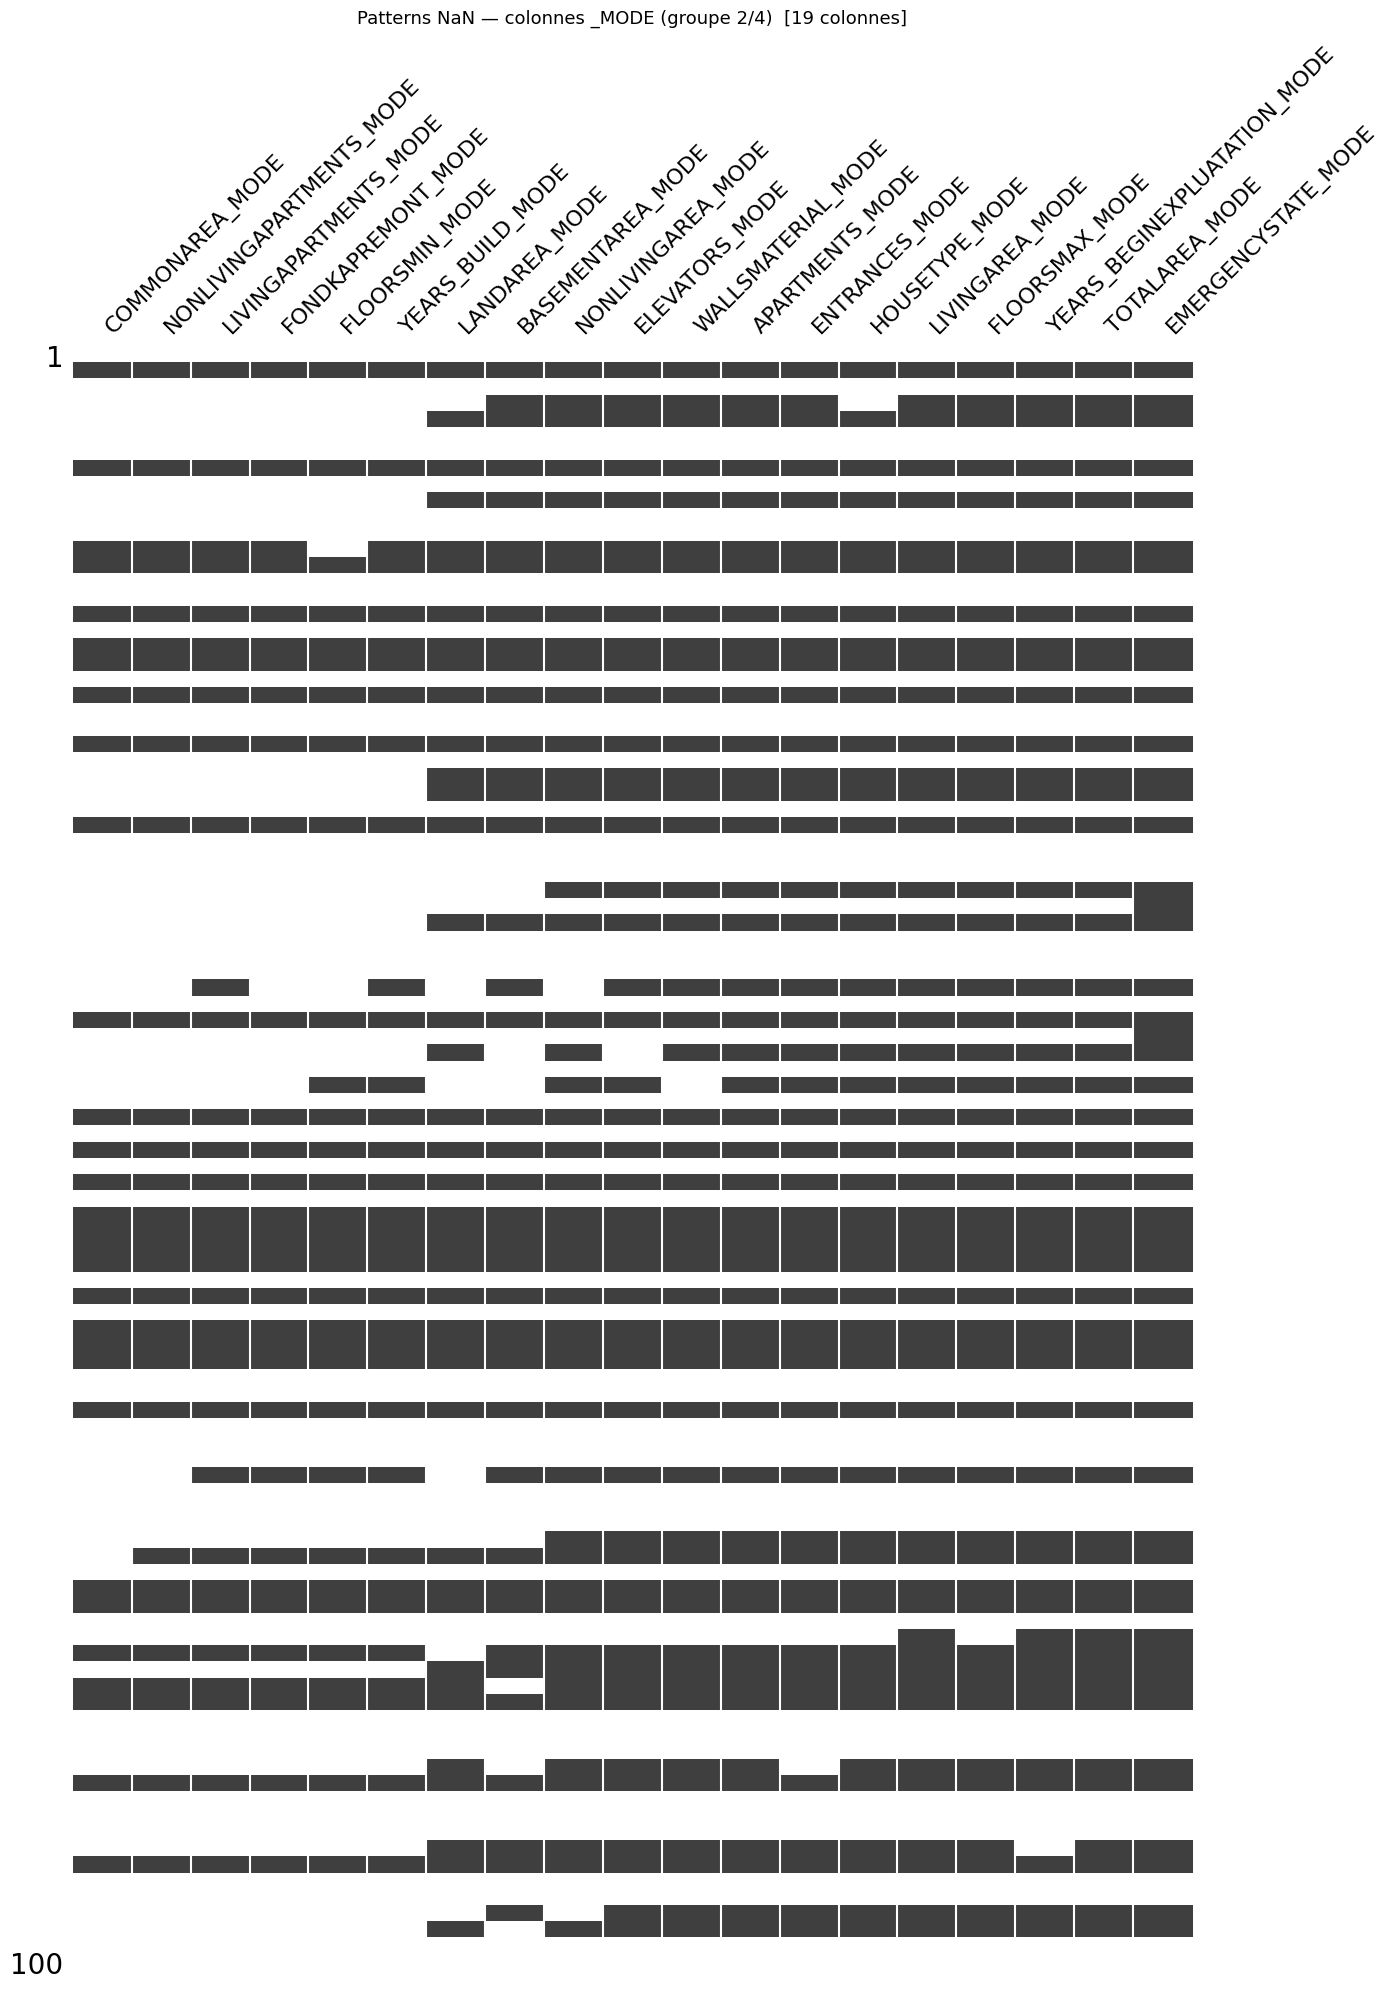

Graphique sauvegardé : graphiques/missingno_mode.png  (19 colonnes)


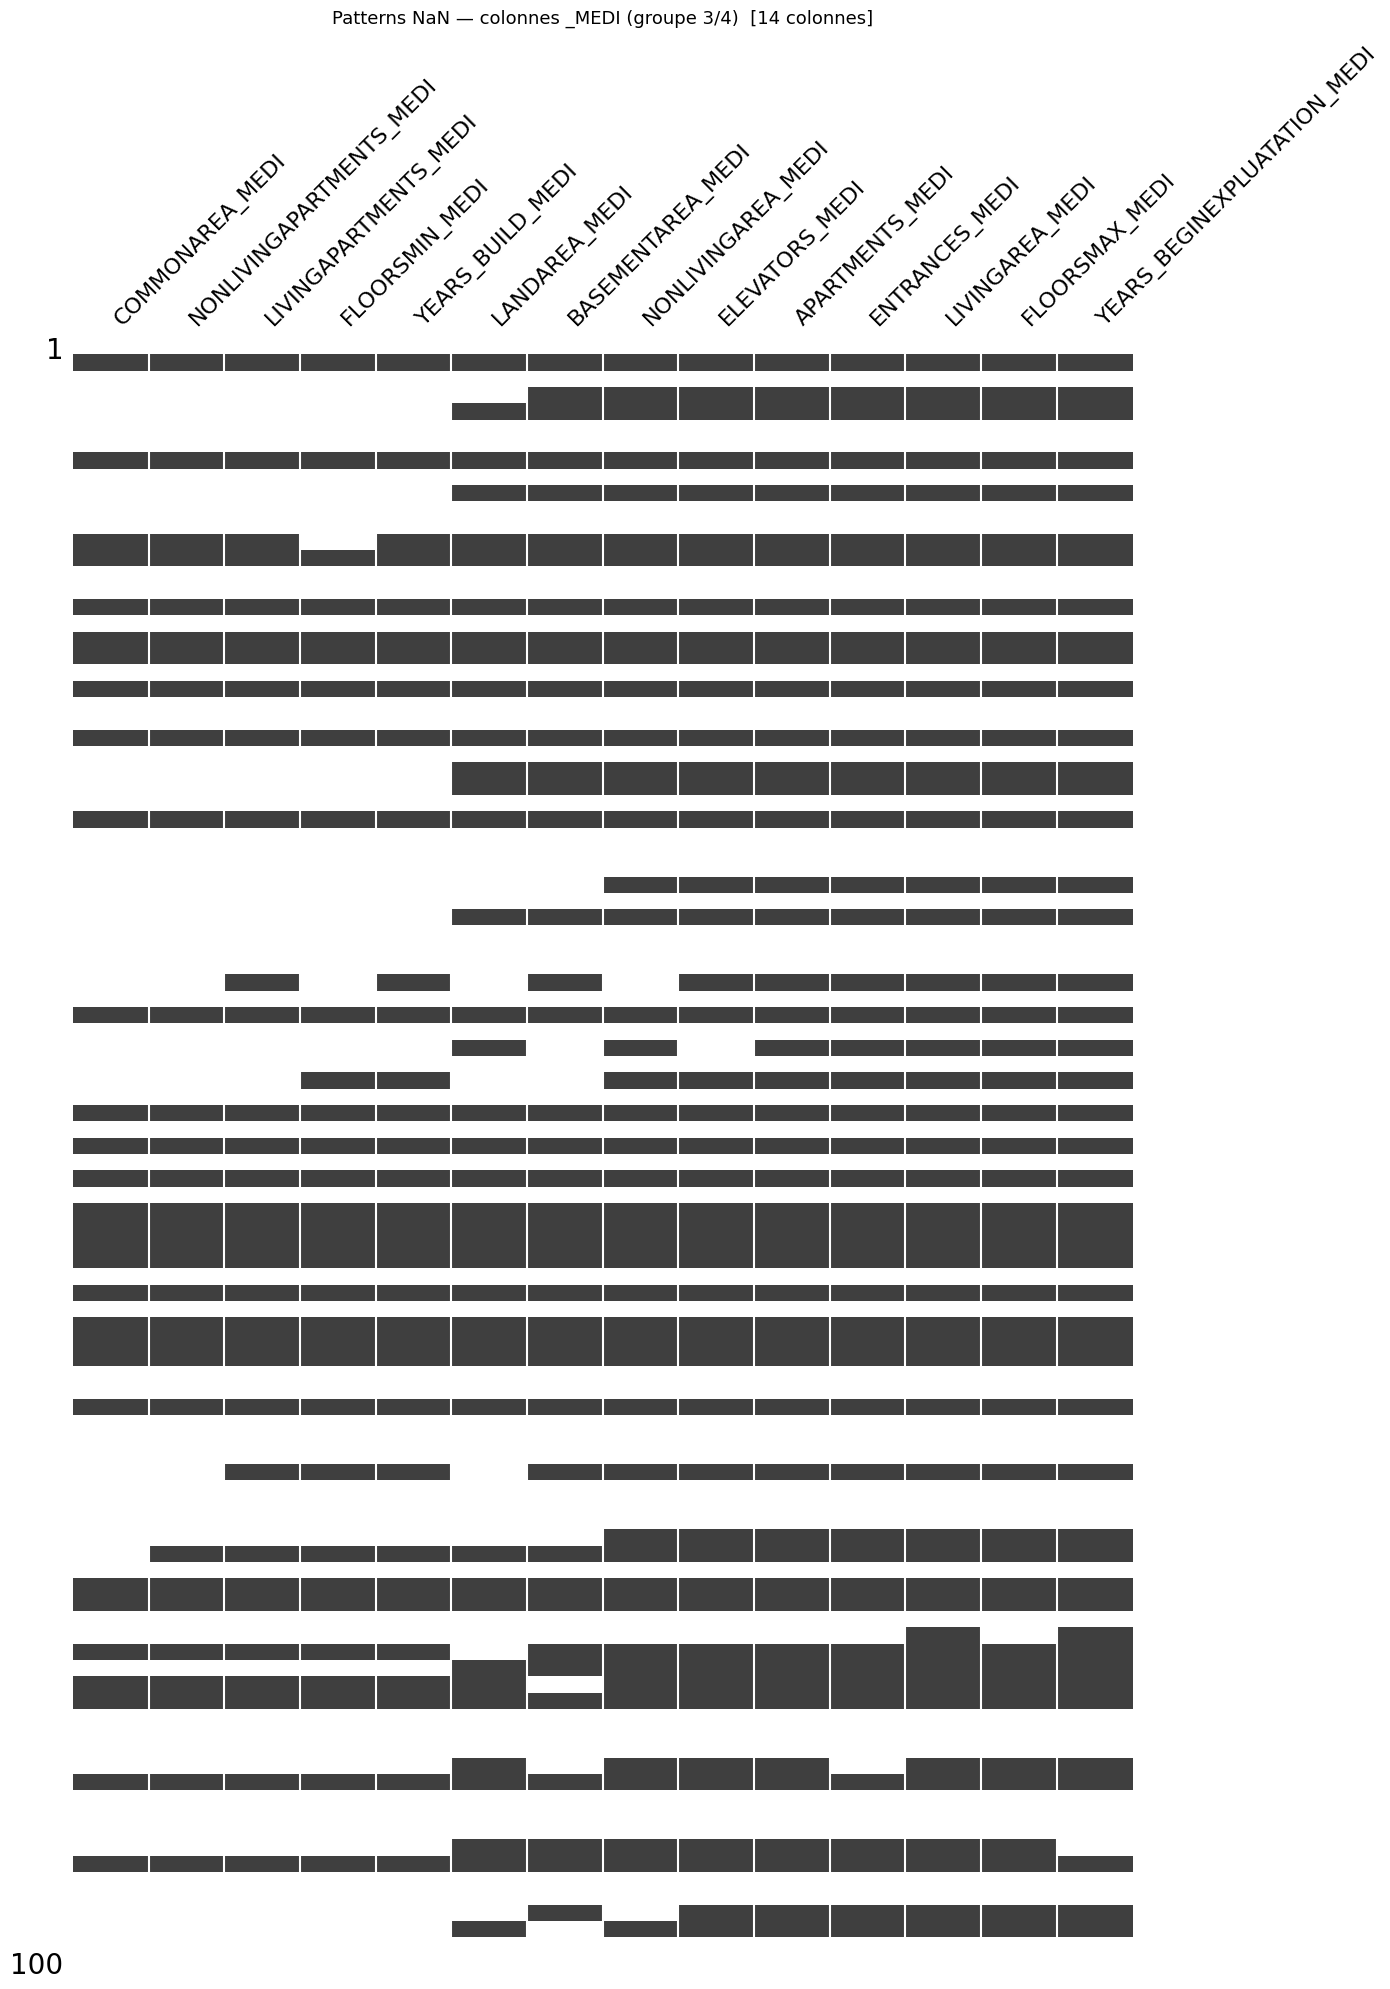

Graphique sauvegardé : graphiques/missingno_medi.png  (14 colonnes)


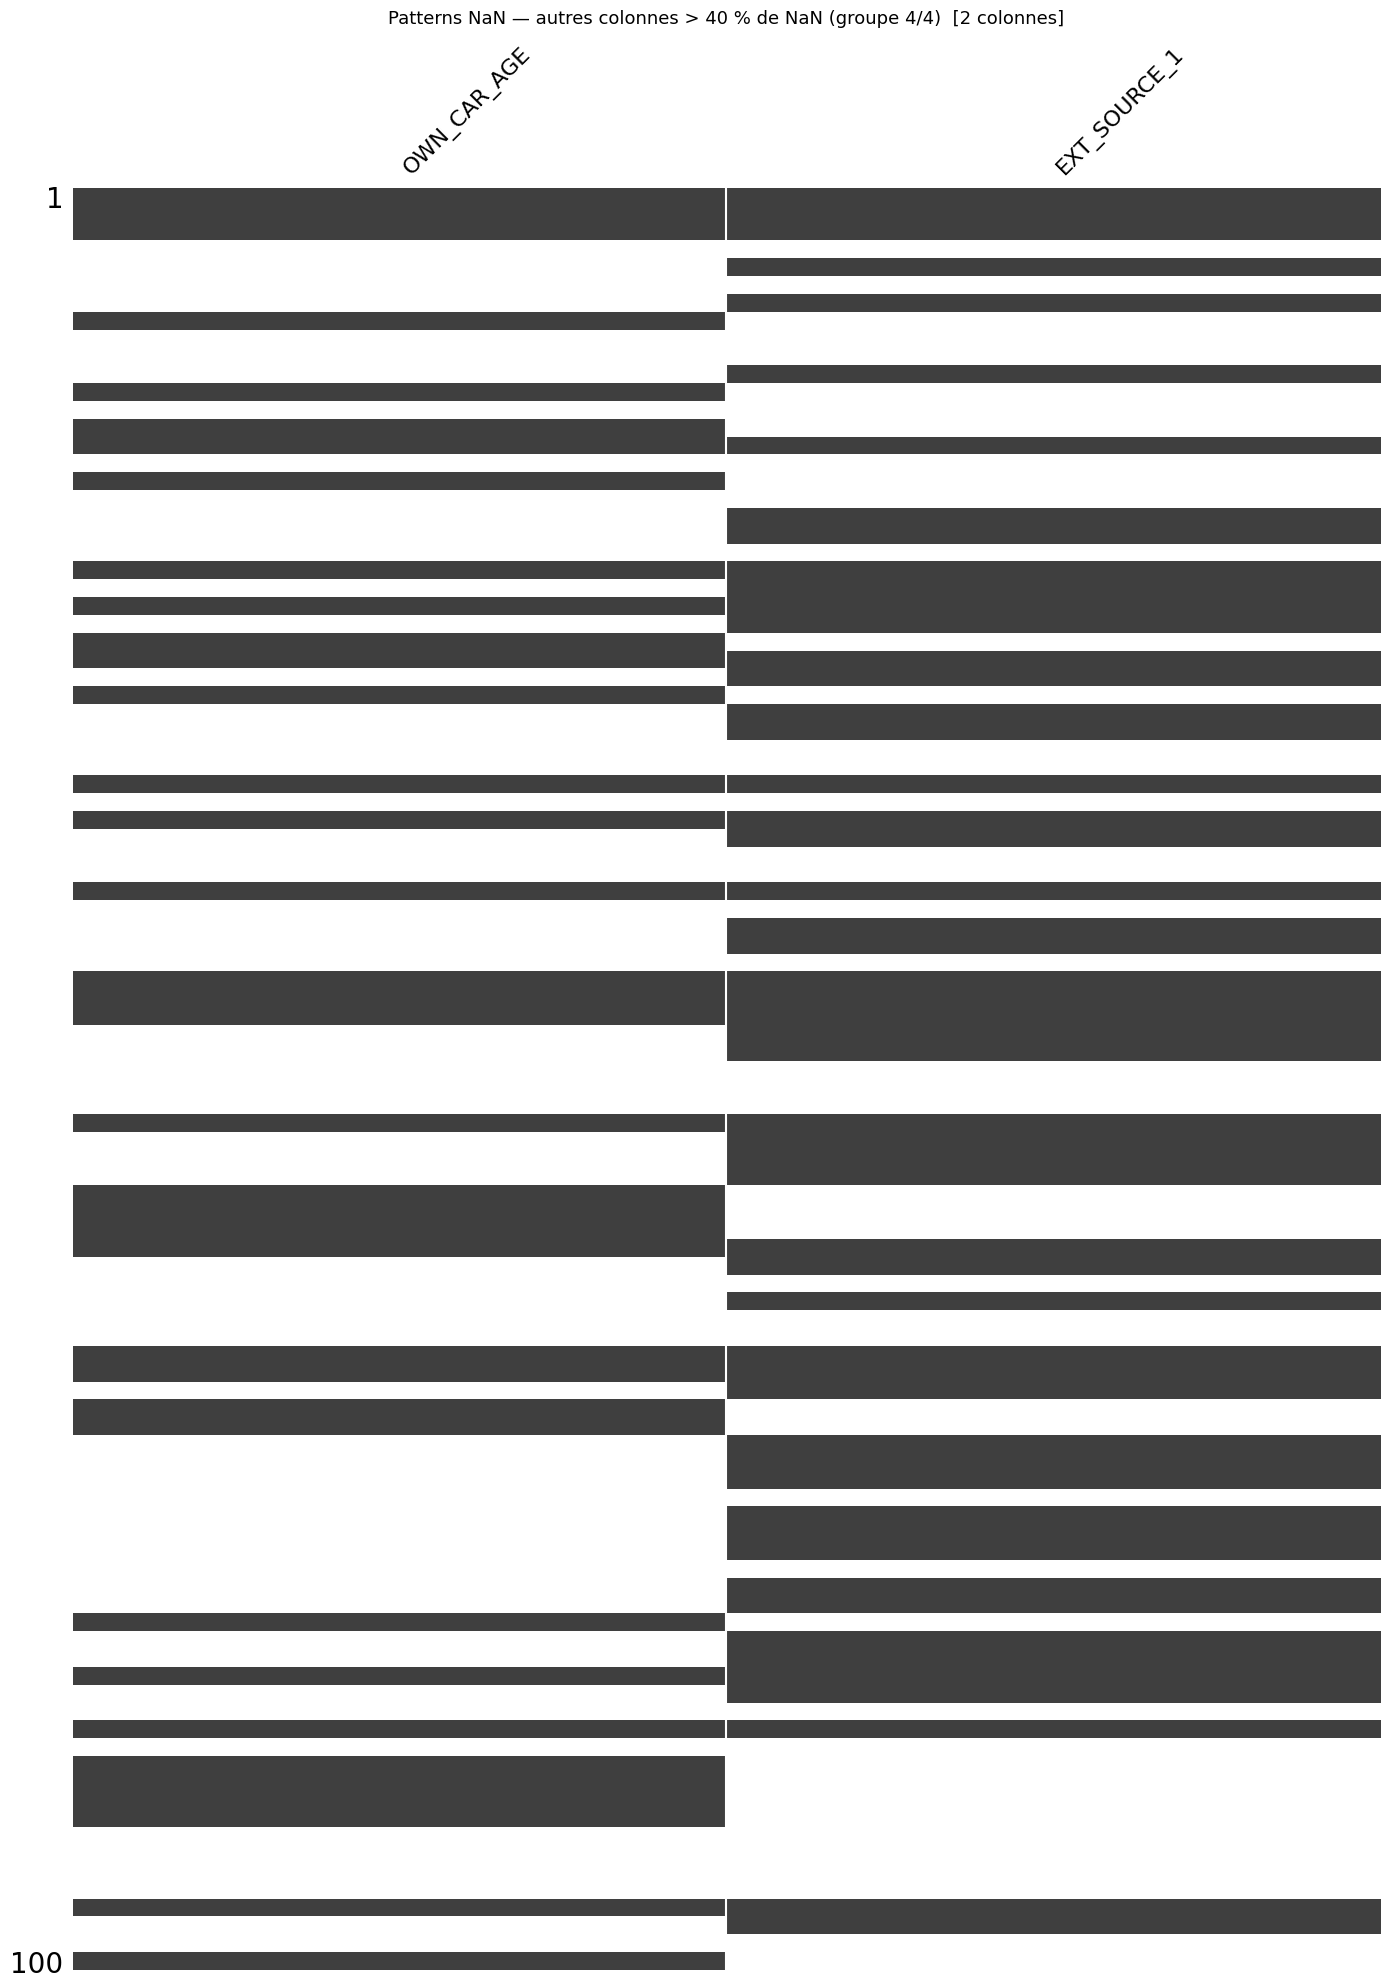

Graphique sauvegardé : graphiques/missingno_reste.png  (2 colonnes)


In [57]:
import missingno as msno
import matplotlib.pyplot as plt
import os

# Colonnes avec plus de 40 % de NaN
cols_sup40 = tableau_nan[tableau_nan['pct_manquants'] > 40].index.tolist()

# Colonnes ne finissant ni par _AVG, ni _MODE, ni _MEDI (ex : OWN_CAR_AGE, EXT_SOURCE_1, ...)
cols_reste = [
    c for c in cols_sup40
    if not c.endswith('_AVG') and not c.endswith('_MODE') and not c.endswith('_MEDI')
]

os.makedirs('graphiques', exist_ok=True)

groupes = [
    ('_AVG',  'missingno_avg.png',    '1/4', cols_sup40),
    ('_MODE', 'missingno_mode.png',   '2/4', cols_sup40),
    ('_MEDI', 'missingno_medi.png',   '3/4', cols_sup40),
    ('',      'missingno_reste.png',  '4/4', cols_reste),
]

for suffixe, fichier, numero, source in groupes:
    cols_groupe = [c for c in source if c.endswith(suffixe)] if suffixe else source

    if not cols_groupe:
        print(f"Groupe {suffixe or 'reste'} : aucune colonne trouvée — graphique ignoré.")
        continue

    df_sample = application_train[cols_groupe].sample(
        n=min(100, len(application_train)), random_state=42
    )

    fig, ax = plt.subplots(figsize=(14, 20))
    msno.matrix(df_sample, ax=ax, sparkline=False)
    label = f"colonnes {suffixe}" if suffixe else "autres colonnes > 40 % de NaN"
    ax.set_title(
        f"Patterns NaN — {label} (groupe {numero})  [{len(cols_groupe)} colonnes]",
        fontsize=13, pad=14
    )
    plt.tight_layout()
    plt.savefig(f'graphiques/{fichier}', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Graphique sauvegardé : graphiques/{fichier}  ({len(cols_groupe)} colonnes)")

In [28]:
# Répartition par seuil de NaN
sup_40   = (tableau_nan['pct_manquants'] > 40).sum()
entre    = ((tableau_nan['pct_manquants'] >= 10) & (tableau_nan['pct_manquants'] <= 40)).sum()
inf_10   = (tableau_nan['pct_manquants'] < 10).sum()

print("=" * 50)
print("RÉPARTITION PAR SEUIL DE NaN")
print("=" * 50)
print(f"  > 40 % de NaN  : {sup_40:>3} colonnes  → candidats à la suppression")
print(f"  10 % à 40 %    : {entre:>3} colonnes  → imputation à envisager")
print(f"  < 10 % de NaN  : {inf_10:>3} colonnes  → imputation simple")
print("=" * 50)

RÉPARTITION PAR SEUIL DE NaN
  > 40 % de NaN  :  49 colonnes  → candidats à la suppression
  10 % à 40 %    :   8 colonnes  → imputation à envisager
  < 10 % de NaN  :  10 colonnes  → imputation simple


---

## Résumé — 1.4 Valeurs manquantes

**67 colonnes sur 122** ont au moins une valeur manquante.

**Répartition par seuil :**

| Seuil | Nb colonnes | Stratégie Phase 2 |
|---|---|---|
| **> 40 % de NaN** | 49 | Suppression — trop peu de données pour imputer |
| **10 % à 40 %** | 8 | Imputation (médiane pour numériques, mode pour catégorielles) |
| **< 10 % de NaN** | 10 | Imputation simple — impact faible |

> Les colonnes à fort taux de NaN appartiennent principalement au groupe des caractéristiques **logement** (`COMMONAREA_*`, `NONLIVINGAPARTMENTS_*`, etc.) — l'information était probablement non collectée pour une grande partie des clients.

---

## Phase 1 — 1.5 Distributions des variables principales

### Objectif
Visualiser la forme des variables clés avant tout nettoyage : détecter les asymétries, valeurs aberrantes et déséquilibres qui guideront les choix de la Phase 2.

### Étape 1 — Variables numériques (grille 2×2)

On affiche les histogrammes de 4 variables numériques clés.
> **Note sur `DAYS_EMPLOYED`** : certaines valeurs valent 365 243 — c'est une valeur sentinelle du dataset Home Credit pour coder "sans emploi". On les filtre avant de tracer.

Sauvegardé : graphiques/distributions_numeriques.png


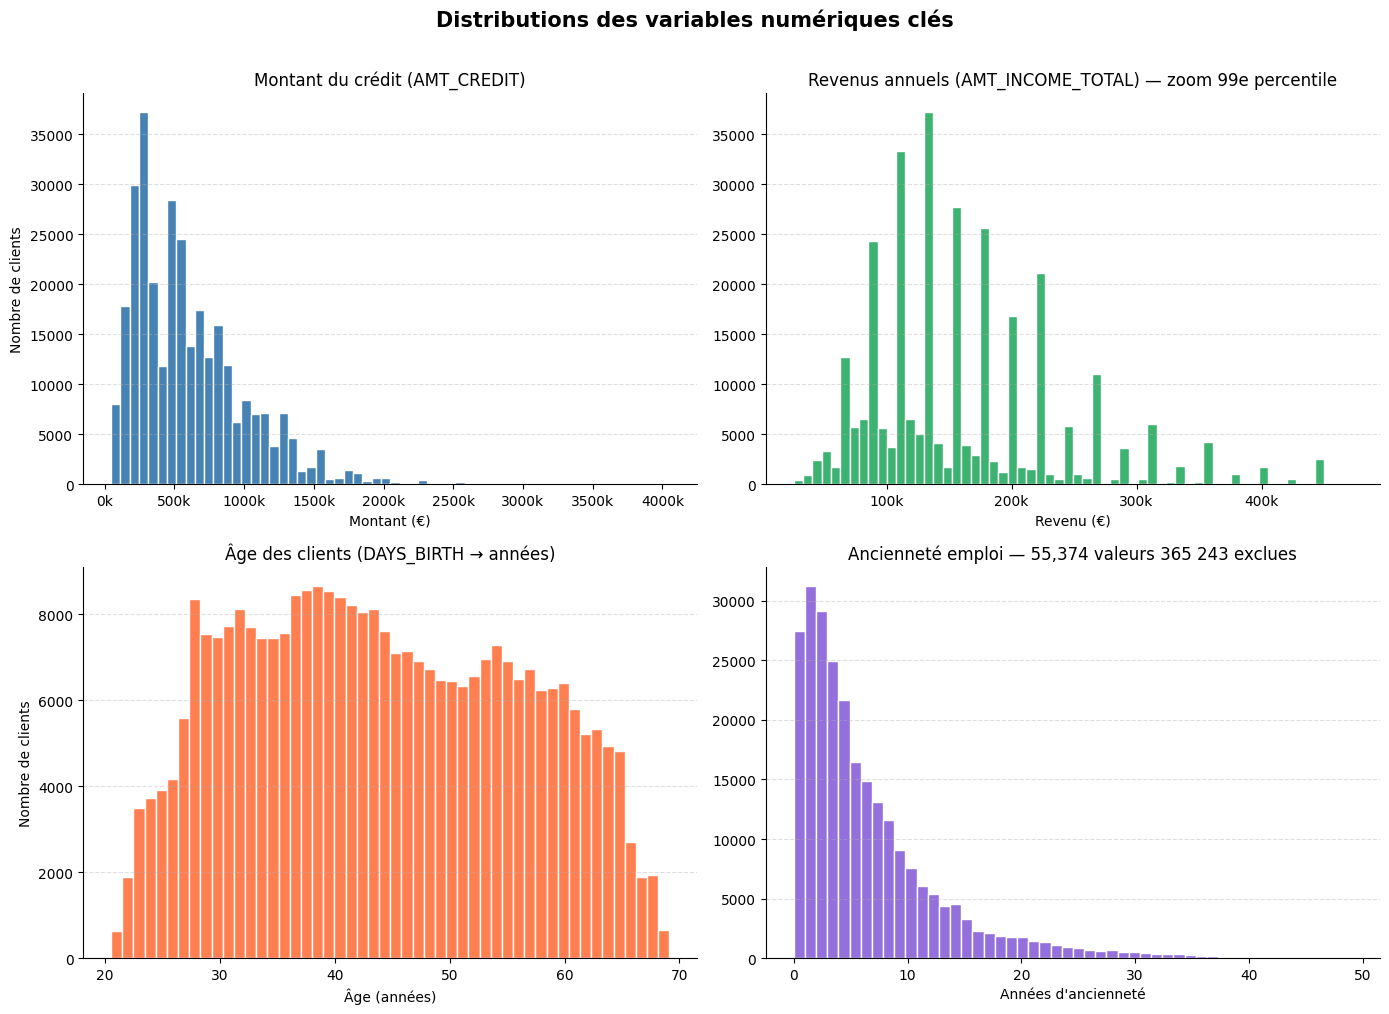

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Préparation des séries (conversions + filtre aberrant)
age_ans          = application_train['DAYS_BIRTH'].abs() / 365
anciennete_ans   = application_train.loc[
    application_train['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED'
].abs() / 365
n_aberrants      = (application_train['DAYS_EMPLOYED'] == 365243).sum()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions des variables numériques clés", fontsize=15, fontweight='bold', y=1.01)

# — AMT_CREDIT
axes[0, 0].hist(application_train['AMT_CREDIT'].dropna(), bins=60, color='steelblue', edgecolor='white')
axes[0, 0].set_title("Montant du crédit (AMT_CREDIT)")
axes[0, 0].set_xlabel("Montant (€)")
axes[0, 0].set_ylabel("Nombre de clients")
axes[0, 0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

# — AMT_INCOME_TOTAL (zoom : on écarte le top 1% pour ne pas écraser le graphique)
revenu_p99 = application_train['AMT_INCOME_TOTAL'].quantile(0.99)
axes[0, 1].hist(application_train.loc[application_train['AMT_INCOME_TOTAL'] <= revenu_p99, 'AMT_INCOME_TOTAL'],
                bins=60, color='mediumseagreen', edgecolor='white')
axes[0, 1].set_title("Revenus annuels (AMT_INCOME_TOTAL) — zoom 99e percentile")
axes[0, 1].set_xlabel("Revenu (€)")
axes[0, 1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

# — ÂGE
axes[1, 0].hist(age_ans, bins=50, color='coral', edgecolor='white')
axes[1, 0].set_title("Âge des clients (DAYS_BIRTH → années)")
axes[1, 0].set_xlabel("Âge (années)")
axes[1, 0].set_ylabel("Nombre de clients")

# — ANCIENNETÉ EMPLOI
axes[1, 1].hist(anciennete_ans, bins=50, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title(f"Ancienneté emploi — {n_aberrants:,} valeurs 365 243 exclues")
axes[1, 1].set_xlabel("Années d'ancienneté")

for ax in axes.flat:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions_numeriques.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/distributions_numeriques.png")
plt.show()

### Étape 2 — Variables catégorielles (grille 2×2)

On visualise 4 variables qualitatives avec leur décompte de modalités.
La 4e variable choisie est `NAME_FAMILY_STATUS` (situation familiale), très liée au profil de risque.

Sauvegardé : graphiques/distributions_categorielles.png


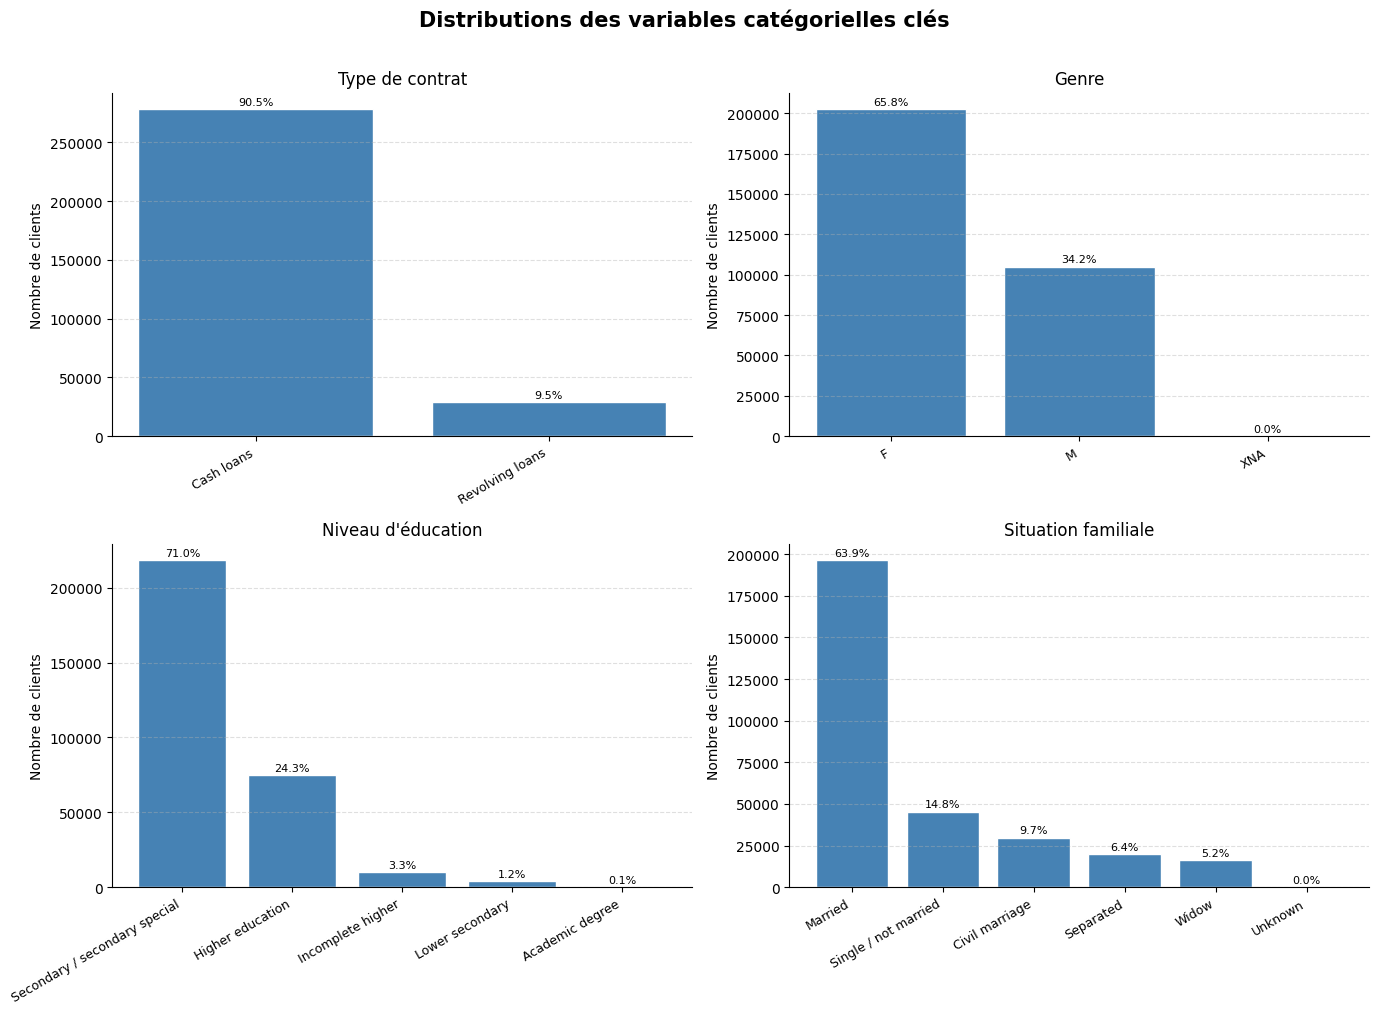

In [30]:
vars_cat = {
    'NAME_CONTRACT_TYPE' : "Type de contrat",
    'CODE_GENDER'        : "Genre",
    'NAME_EDUCATION_TYPE': "Niveau d'éducation",
    'NAME_FAMILY_STATUS' : "Situation familiale",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Distributions des variables catégorielles clés", fontsize=15, fontweight='bold', y=1.01)

for ax, (col, titre) in zip(axes.flat, vars_cat.items()):
    counts = application_train[col].value_counts()
    bars = ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
    ax.set_title(titre)
    ax.set_ylabel("Nombre de clients")
    # Pourcentage au-dessus de chaque barre
    total = counts.sum()
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                f"{val/total:.1%}", ha='center', va='bottom', fontsize=8)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/distributions_categorielles.png', dpi=150, bbox_inches='tight')
print("Sauvegardé : graphiques/distributions_categorielles.png")
plt.show()

---

## Résumé — 1.5 Distributions des variables principales

### Variables numériques

| Variable | Observation clé | Anomalie repérée |
|---|---|---|
| **AMT_CREDIT** | Distribution asymétrique à droite — la majorité des crédits sont petits, quelques très grands crédits tirent la queue vers la droite | Pas de valeur aberrante technique, mais des outliers extrêmes à surveiller |
| **AMT_INCOME_TOTAL** | Forte asymétrie droite — quelques revenus très élevés (top 1 % filtré pour le graphique) écrasent la majorité | Outliers à plusieurs millions → à plafonner ou logger en Phase 2 |
| **DAYS_BIRTH (âge)** | Distribution relativement uniforme entre 20 et 70 ans, légère sur-représentation des 30–50 ans | Aucune valeur aberrante |
| **DAYS_EMPLOYED (ancienneté)** | Concentrée sur 0–15 ans, queue droite modérée | **365 243** présent pour ~55 000 clients — valeur sentinelle "sans emploi" à remplacer par NaN en Phase 2 |

### Variables catégorielles

| Variable | Observation clé |
|---|---|
| **NAME_CONTRACT_TYPE** | Très déséquilibré : les crédits Cash dominent largement face aux Revolving |
| **CODE_GENDER** | Majorité de femmes (~65 %) — la variable XNA (indéfini) devra être traitée |
| **NAME_EDUCATION_TYPE** | Le niveau "Secondary / secondary special" est de loin le plus représenté |
| **NAME_FAMILY_STATUS** | "Married" domine, suivi de "Single/not married" — information utile pour le scoring |

#### Vérification — Identification des clients avec DAYS_EMPLOYED = 365 243

Avant de passer en Phase 2, on confirme l'origine de la valeur sentinelle et on crée le flag d'anomalie qui sera conservé comme feature.

In [31]:
# Qui sont les clients avec DAYS_EMPLOYED = 365243 ?
mask = application_train['DAYS_EMPLOYED'] == 365243

print(application_train[mask]['NAME_INCOME_TYPE'].value_counts())

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


In [32]:
# Étape 1 : créer le flag AVANT de remplacer
application_train['FLAG_EMPLOYED_ANOMALY'] = (
    application_train['DAYS_EMPLOYED'] == 365243
).astype(int)

# Étape 2 : remplacer par NaN
application_train['DAYS_EMPLOYED'] = application_train['DAYS_EMPLOYED'].replace(
    365243, np.nan
)

---

## Phase 2 — Nettoyage des données

---

### 2.1 Gestion des valeurs manquantes

**Objectif** : Supprimer les colonnes trop vides (> 40 % de NaN), traiter les cas particuliers (`OWN_CAR_AGE`, `DAYS_EMPLOYED`), imputer le reste.

In [33]:
# Phase 2 — 2.1 Suppression des colonnes avec trop de valeurs manquantes
df_train = application_train.copy()

# Taux de NaN par colonne
nan_rate = df_train.isnull().mean()

# Colonnes avec plus de 40 % de valeurs manquantes
cols_to_drop = nan_rate[nan_rate > 0.40].index.tolist()

print(f"Colonnes avec > 40 % de NaN : {len(cols_to_drop)}")
print(cols_to_drop)

# Suppression
df_train.drop(columns=cols_to_drop, inplace=True)

print(f"\nNouvelle forme : {df_train.shape}")

Colonnes avec > 40 % de NaN : 49
['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BEGINEXPLUATATION_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMAX_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BEGINEXPLUATATION_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMAX_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI', 'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'TOTALAREA_MODE', 'WALLSMAT

In [34]:
# --- Récupération et imputation de OWN_CAR_AGE ---

# 1. Récupérer OWN_CAR_AGE depuis le dataframe original et l'ajouter à df_train
df_train['OWN_CAR_AGE'] = application_train['OWN_CAR_AGE']

# 2. NaN dans OWN_CAR_AGE selon FLAG_OWN_CAR
print("NaN dans OWN_CAR_AGE par valeur de FLAG_OWN_CAR :")
print(df_train.groupby('FLAG_OWN_CAR')['OWN_CAR_AGE'].apply(lambda x: x.isna().sum()).rename('nb_NaN'))

# 3. Imputation
#    - Pas de voiture (N) → 0
df_train.loc[df_train['FLAG_OWN_CAR'] == 'N', 'OWN_CAR_AGE'] = 0

#    - A une voiture (Y) mais âge inconnu → médiane des propriétaires
median_car_age = df_train.loc[df_train['FLAG_OWN_CAR'] == 'Y', 'OWN_CAR_AGE'].median()
df_train.loc[
    (df_train['FLAG_OWN_CAR'] == 'Y') & (df_train['OWN_CAR_AGE'].isna()),
    'OWN_CAR_AGE'
] = median_car_age
print(f"\nMédiane utilisée pour les propriétaires sans âge connu : {median_car_age} ans")

# 4. Vérification : plus aucun NaN
remaining_nan = df_train['OWN_CAR_AGE'].isna().sum()
print(f"\nNaN restants dans OWN_CAR_AGE : {remaining_nan}")
assert remaining_nan == 0, "Il reste des NaN dans OWN_CAR_AGE !"

# 5. Confirmation du shape : doit afficher 75 colonnes
print(f"\ndf_train.shape : {df_train.shape}  ← 75 colonnes attendues")

NaN dans OWN_CAR_AGE par valeur de FLAG_OWN_CAR :
FLAG_OWN_CAR
N    202924
Y         5
Name: nb_NaN, dtype: int64

Médiane utilisée pour les propriétaires sans âge connu : 9.0 ans

NaN restants dans OWN_CAR_AGE : 0

df_train.shape : (307511, 75)  ← 75 colonnes attendues


In [35]:
# --- Traitement de DAYS_EMPLOYED dans df_train ---

# 1. FLAG_EMPLOYED_ANOMALY (créé sur application_train avant la copie → déjà dans df_train)
#    On affiche le nombre d'anomalies détectées
n_anomalies = df_train['FLAG_EMPLOYED_ANOMALY'].sum()
print(f"Nombre de clients avec FLAG_EMPLOYED_ANOMALY == 1 : {n_anomalies:,}")

# 2. Remplacement défensif : s'assurer qu'aucun 365243 ne subsiste dans df_train
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].replace(365243, np.nan)

# 3. Imputation des NaN avec la médiane (hors anomalies, donc hors NaN)
median_days_employed = df_train['DAYS_EMPLOYED'].median()
df_train['DAYS_EMPLOYED'] = df_train['DAYS_EMPLOYED'].fillna(median_days_employed)
print(f"Médiane utilisée pour l'imputation : {median_days_employed:.0f} jours")

# 4. Vérification : aucun NaN ne doit subsister
nan_remaining = df_train['DAYS_EMPLOYED'].isna().sum()
print(f"NaN restants dans DAYS_EMPLOYED : {nan_remaining}")
assert nan_remaining == 0, "Il reste des NaN dans DAYS_EMPLOYED !"

# 5. Statistiques pour confirmer que 365243 a disparu
print("\nStatistiques de DAYS_EMPLOYED après imputation :")
print(df_train['DAYS_EMPLOYED'].describe())

Nombre de clients avec FLAG_EMPLOYED_ANOMALY == 1 : 55,374
Médiane utilisée pour l'imputation : -1648 jours
NaN restants dans DAYS_EMPLOYED : 0

Statistiques de DAYS_EMPLOYED après imputation :
count    307511.000000
mean      -2251.606131
std        2136.193492
min      -17912.000000
25%       -2760.000000
50%       -1648.000000
75%        -933.000000
max           0.000000
Name: DAYS_EMPLOYED, dtype: float64


In [36]:
# Phase 2 — 2.1 Imputation des valeurs manquantes restantes dans df_train

# --- Étape 1 : état des lieux ---
nan_par_col = df_train.isnull().sum()
cols_nan = nan_par_col[nan_par_col > 0]

print("=" * 55)
print(f"COLONNES AVEC DES NaN RESTANTS : {len(cols_nan)}")
print("=" * 55)
for col, n in cols_nan.items():
    print(f"  {col:<45} {n:>6,}")
print("=" * 55)

# --- Étape 2 : imputation des colonnes numériques avec la médiane ---
num_cols_nan = df_train[cols_nan.index].select_dtypes(include='number').columns.tolist()
for col in num_cols_nan:
    mediane = df_train[col].median()
    df_train[col] = df_train[col].fillna(mediane)

print(f"\nColonnes numériques imputées avec la médiane ({len(num_cols_nan)}) :")
print(num_cols_nan)

# --- Étape 3 : imputation des colonnes catégorielles avec le mode ---
cat_cols_nan = df_train[cols_nan.index].select_dtypes(include='object').columns.tolist()
for col in cat_cols_nan:
    mode = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(mode)

print(f"\nColonnes catégorielles imputées avec le mode ({len(cat_cols_nan)}) :")
print(cat_cols_nan)

# --- Étape 4 : vérification — aucun NaN ne doit subsister ---
total_nan = df_train.isnull().sum().sum()
print(f"\n{'=' * 55}")
print(f"NaN restants dans df_train (total) : {total_nan}")
assert total_nan == 0, f"Il reste {total_nan} NaN dans df_train !"
print("Aucun NaN restant — imputation complète.")
print("=" * 55)

# --- Étape 5 : confirmation du shape ---
print(f"\ndf_train.shape : {df_train.shape}")

COLONNES AVEC DES NaN RESTANTS : 18
  AMT_ANNUITY                                       12
  AMT_GOODS_PRICE                                  278
  NAME_TYPE_SUITE                                1,292
  OCCUPATION_TYPE                               96,391
  CNT_FAM_MEMBERS                                    2
  EXT_SOURCE_2                                     660
  EXT_SOURCE_3                                  60,965
  OBS_30_CNT_SOCIAL_CIRCLE                       1,021
  DEF_30_CNT_SOCIAL_CIRCLE                       1,021
  OBS_60_CNT_SOCIAL_CIRCLE                       1,021
  DEF_60_CNT_SOCIAL_CIRCLE                       1,021
  DAYS_LAST_PHONE_CHANGE                             1
  AMT_REQ_CREDIT_BUREAU_HOUR                    41,519
  AMT_REQ_CREDIT_BUREAU_DAY                     41,519
  AMT_REQ_CREDIT_BUREAU_WEEK                    41,519
  AMT_REQ_CREDIT_BUREAU_MON                     41,519
  AMT_REQ_CREDIT_BUREAU_QRT                     41,519
  AMT_REQ_CREDIT_BUREAU_YEAR 

---

## Résumé — 2.1 Gestion des valeurs manquantes

| Étape | Action | Résultat |
|---|---|---|
| **Suppression colonnes > 40 % NaN** | 49 colonnes supprimées | 122 → 74 colonnes, puis 75 après réintégration de OWN_CAR_AGE |
| **OWN_CAR_AGE** | 0 si pas de voiture ; médiane = 9 ans si propriétaire sans âge connu | 202 929 NaN résolus |
| **DAYS_EMPLOYED** | Valeur sentinelle 365 243 → `FLAG_EMPLOYED_ANOMALY` créé + imputation médiane | 55 374 anomalies traitées |
| **Colonnes numériques (16)** | Imputation par médiane | `AMT_ANNUITY`, `EXT_SOURCE_2/3`, `AMT_REQ_CREDIT_BUREAU_*`, … |
| **Colonnes catégorielles (2)** | Imputation par mode | `NAME_TYPE_SUITE`, `OCCUPATION_TYPE` |

**Résultat final :** `df_train` — **307 511 lignes × 75 colonnes**, **0 NaN restant**.

---

### 2.2 Traitement des valeurs aberrantes

**Objectif** : Identifier les distributions très asymétriques (`AMT_INCOME_TOTAL`, `AMT_CREDIT`) et les normaliser par transformation logarithmique pour limiter l'influence des valeurs extrêmes sur le modèle.

STATISTIQUES — AVANT TRANSFORMATION LOG
       AMT_INCOME_TOTAL  AMT_CREDIT
count          307511.0    307511.0
mean           168798.0    599026.0
std            237123.0    402491.0
min             25650.0     45000.0
25%            112500.0    270000.0
50%            147150.0    513531.0
75%            202500.0    808650.0
max         117000000.0   4050000.0

Graphique sauvegardé : graphiques/log_transform.png


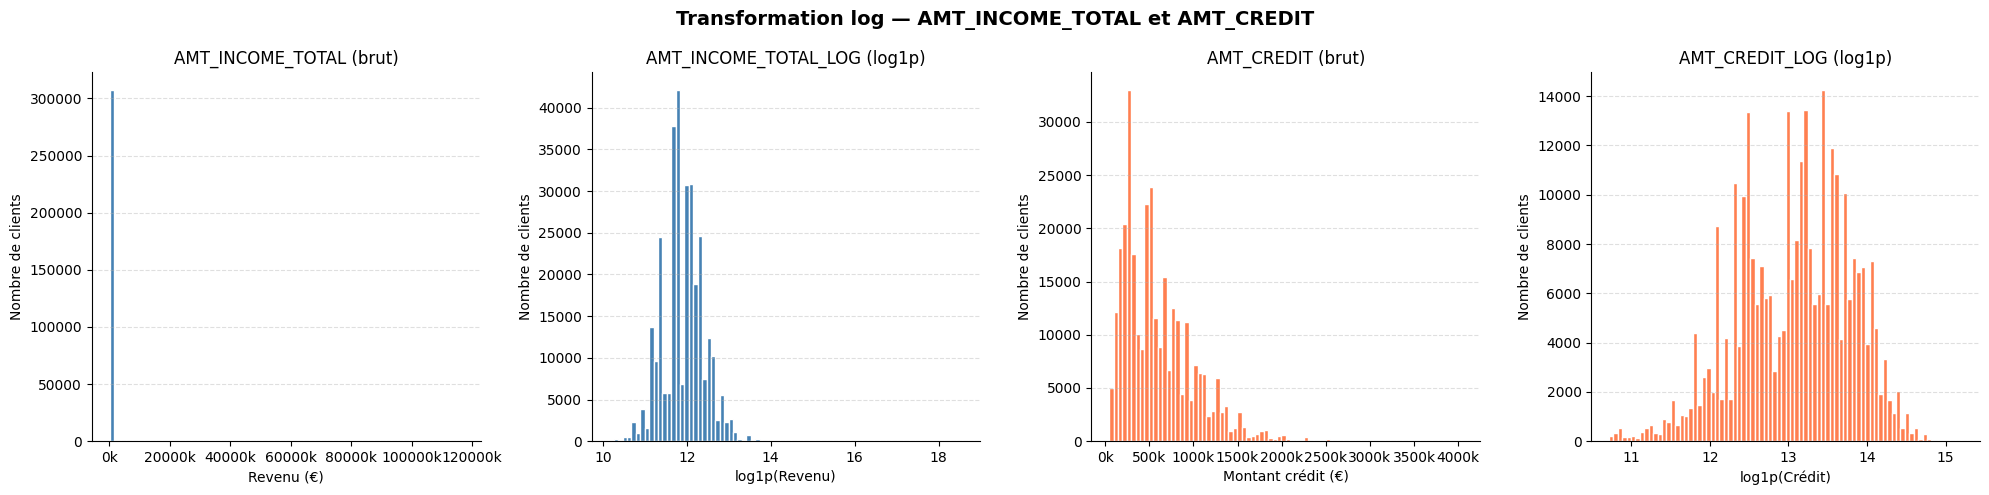


df_train.shape : (307511, 77)  ← 77 colonnes attendues (+2 colonnes log)


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# --- Étape 1 : statistiques avant transformation ---
print("=" * 55)
print("STATISTIQUES — AVANT TRANSFORMATION LOG")
print("=" * 55)
print(df_train[['AMT_INCOME_TOTAL', 'AMT_CREDIT']].describe().round(0).to_string())

# --- Étape 2 : colonnes log ---
df_train['AMT_INCOME_TOTAL_LOG'] = np.log1p(df_train['AMT_INCOME_TOTAL'])
df_train['AMT_CREDIT_LOG']       = np.log1p(df_train['AMT_CREDIT'])

# --- Étape 3 : 4 histogrammes côte à côte ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Transformation log — AMT_INCOME_TOTAL et AMT_CREDIT",
             fontsize=14, fontweight='bold')

axes[0].hist(df_train['AMT_INCOME_TOTAL'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_title("AMT_INCOME_TOTAL (brut)")
axes[0].set_xlabel("Revenu (€)")
axes[0].set_ylabel("Nombre de clients")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

axes[1].hist(df_train['AMT_INCOME_TOTAL_LOG'], bins=80, color='steelblue', edgecolor='white')
axes[1].set_title("AMT_INCOME_TOTAL_LOG (log1p)")
axes[1].set_xlabel("log1p(Revenu)")
axes[1].set_ylabel("Nombre de clients")

axes[2].hist(df_train['AMT_CREDIT'], bins=80, color='coral', edgecolor='white')
axes[2].set_title("AMT_CREDIT (brut)")
axes[2].set_xlabel("Montant crédit (€)")
axes[2].set_ylabel("Nombre de clients")
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x/1000)}k"))

axes[3].hist(df_train['AMT_CREDIT_LOG'], bins=80, color='coral', edgecolor='white')
axes[3].set_title("AMT_CREDIT_LOG (log1p)")
axes[3].set_xlabel("log1p(Crédit)")
axes[3].set_ylabel("Nombre de clients")

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('graphiques/log_transform.png', dpi=150, bbox_inches='tight')
print("\nGraphique sauvegardé : graphiques/log_transform.png")
plt.show()

# --- Étape 4 : confirmation du shape ---
print(f"\ndf_train.shape : {df_train.shape}  ← 77 colonnes attendues (+2 colonnes log)")

---

## Résumé — 2.2 Traitement des valeurs aberrantes

| Variable | Problème observé | Traitement appliqué | Nouvelle colonne |
|---|---|---|---|
| **AMT_INCOME_TOTAL** | Forte asymétrie droite — quelques revenus à plusieurs millions écrasent la majorité | Transformation `log1p` | `AMT_INCOME_TOTAL_LOG` |
| **AMT_CREDIT** | Asymétrie droite modérée — queue longue vers les gros crédits | Transformation `log1p` | `AMT_CREDIT_LOG` |

**Pourquoi `log1p` ?** Elle compresse les grandes valeurs, rapproche la distribution d'une gaussienne et est robuste aux zéros (`log(0)` indéfini, `log1p(0) = 0`).

**Résultat :** `df_train` passe de 75 à **77 colonnes** — les colonnes brutes sont conservées pour traçabilité.

---

### 2.3 Encodage des variables catégorielles

**Objectif** : Convertir toutes les colonnes `object` de `df_train` en valeurs numériques exploitables par le modèle — via Label Encoding (2 modalités) ou One-Hot Encoding (> 2 modalités).

In [38]:
# --- Étape 1 : État des lieux — colonnes object et leurs modalités ---
obj_cols = df_train.select_dtypes(include='object').columns.tolist()

print("=" * 55)
print(f"COLONNES DE TYPE object : {len(obj_cols)}")
print("=" * 55)

for col in obj_cols:
    print(f"\n▶ {col}  ({df_train[col].nunique()} modalités)")
    print(df_train[col].value_counts().to_string())

COLONNES DE TYPE object : 12

▶ NAME_CONTRACT_TYPE  (2 modalités)
NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279

▶ CODE_GENDER  (3 modalités)
CODE_GENDER
F      202448
M      105059
XNA         4

▶ FLAG_OWN_CAR  (2 modalités)
FLAG_OWN_CAR
N    202924
Y    104587

▶ FLAG_OWN_REALTY  (2 modalités)
FLAG_OWN_REALTY
Y    213312
N     94199

▶ NAME_TYPE_SUITE  (7 modalités)
NAME_TYPE_SUITE
Unaccompanied      249818
Family              40149
Spouse, partner     11370
Children             3267
Other_B              1770
Other_A               866
Group of people       271

▶ NAME_INCOME_TYPE  (8 modalités)
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5

▶ NAME_EDUCATION_TYPE  (5 modalités)
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher 

In [39]:
# --- Étape 2 : Traitement de CODE_GENDER — remplacement de XNA par le mode ---
n_xna = (df_train['CODE_GENDER'] == 'XNA').sum()
mode_gender = df_train.loc[df_train['CODE_GENDER'] != 'XNA', 'CODE_GENDER'].mode()[0]

df_train['CODE_GENDER'] = df_train['CODE_GENDER'].replace('XNA', mode_gender)

print(f"Valeurs XNA remplacées : {n_xna}")
print(f"Mode utilisé           : {mode_gender}")
print("\nDistribution CODE_GENDER après remplacement :")
print(df_train['CODE_GENDER'].value_counts())

Valeurs XNA remplacées : 4
Mode utilisé           : F

Distribution CODE_GENDER après remplacement :
CODE_GENDER
F    202452
M    105059
Name: count, dtype: int64


In [40]:
# --- Étape 3 : Label Encoding — colonnes object avec exactement 2 modalités ---
from sklearn.preprocessing import LabelEncoder

obj_cols = df_train.select_dtypes(include='object').columns.tolist()
label_encoded_cols = [col for col in obj_cols if df_train[col].nunique() == 2]

le = LabelEncoder()
for col in label_encoded_cols:
    df_train[col] = le.fit_transform(df_train[col])

print(f"Colonnes encodées en Label Encoding ({len(label_encoded_cols)}) :")
for col in label_encoded_cols:
    print(f"  {col}")

Colonnes encodées en Label Encoding (4) :
  NAME_CONTRACT_TYPE
  CODE_GENDER
  FLAG_OWN_CAR
  FLAG_OWN_REALTY


In [41]:
# --- Étape 4 : One-Hot Encoding — colonnes object restantes (> 2 modalités) ---
obj_cols_remaining = df_train.select_dtypes(include='object').columns.tolist()

n_cols_before = df_train.shape[1]
df_train = pd.get_dummies(df_train, columns=obj_cols_remaining, drop_first=False, dtype=int)
n_cols_after = df_train.shape[1]

nouvelles_cols = n_cols_after - n_cols_before + len(obj_cols_remaining)
print(f"Colonnes OHE appliqué sur ({len(obj_cols_remaining)}) : {obj_cols_remaining}")
print(f"\nNombre de nouvelles colonnes créées : {nouvelles_cols}")
print(f"Shape après OHE : {df_train.shape}")

Colonnes OHE appliqué sur (8) : ['NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE']

Nombre de nouvelles colonnes créées : 115
Shape après OHE : (307511, 184)


In [42]:
# --- Étape 5 : Vérification — aucune colonne object ne doit subsister ---
obj_restantes = df_train.select_dtypes(include='object').columns.tolist()

print("=" * 55)
print("VÉRIFICATION — COLONNES object RESTANTES")
print("=" * 55)
if len(obj_restantes) == 0:
    print("  Aucune colonne de type object — encodage complet.")
else:
    print(f"  ATTENTION : {len(obj_restantes)} colonne(s) object restante(s) !")
    print(obj_restantes)

print(f"\ndf_train.shape : {df_train.shape}")

VÉRIFICATION — COLONNES object RESTANTES
  Aucune colonne de type object — encodage complet.

df_train.shape : (307511, 184)
